In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_df = pd.read_csv("../data/processed/train_FD001_labeled.csv")
test_df = pd.read_csv("../data/processed/test_FD001_labeled_final_rows.csv")

print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

Training data shape: (20631, 30)
Test data shape: (100, 30)


,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL,risk_label,high_risk_flag
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,0.03,392,2388,100.0,39.06,23.4190,192,191,Low Risk,0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,0.03,392,2388,100.0,39.00,23.4236,192,190,Low Risk,0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,0.03,390,2388,100.0,38.95,23.3442,192,189,Low Risk,0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,0.03,392,2388,100.0,38.88,23.3739,192,188,Low Risk,0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,0.03,393,2388,100.0,38.90,23.4044,192,187,Low Risk,0


,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_test_cycle,RUL,risk_label,high_risk_flag
0,1,31,-0.0006,0.0004,100.0,518.67,642.58,1581.22,1398.91,14.62,...,0.03,393,2388,100.0,38.81,23.3552,31,112,Low Risk,0
1,2,49,0.0018,-0.0001,100.0,518.67,642.55,1586.59,1410.83,14.62,...,0.03,391,2388,100.0,38.81,23.2618,49,98,Low Risk,0
2,3,126,-0.0016,0.0004,100.0,518.67,642.88,1589.75,1418.89,14.62,...,0.03,395,2388,100.0,38.93,23.2740,126,69,Medium Risk,0
3,4,106,0.0012,0.0004,100.0,518.67,642.78,1594.53,1406.88,14.62,...,0.03,395,2388,100.0,38.58,23.2581,106,82,Low Risk,0
4,5,98,-0.0013,-0.0004,100.0,518.67,642.27,1589.94,1419.36,14.62,...,0.03,394,2388,100.0,38.75,23.4117,98,91,Low Risk,0


In [3]:
print("Training rows:", len(train_df))
print("Training engines:", train_df["unit_number"].nunique())

print("Test rows:", len(test_df))
print("Test engines:", test_df["unit_number"].nunique())

print("\nTraining columns:")
print(train_df.columns.tolist())

Training rows: 20631
Training engines: 100
Test rows: 100
Test engines: 100

Training columns:
['unit_number', 'time_in_cycles', 'operational_setting_1', 'operational_setting_2', 'operational_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'max_cycle', 'RUL', 'risk_label', 'high_risk_flag']


In [4]:
engine_life = (
    train_df
    .groupby("unit_number")["time_in_cycles"]
    .max()
    .reset_index()
    .rename(columns={"time_in_cycles": "engine_lifetime_cycles"})
)

display(engine_life.head())

print("Engine lifetime summary:")
display(engine_life["engine_lifetime_cycles"].describe())

,unit_number,engine_lifetime_cycles
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269


Engine lifetime summary:


count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: engine_lifetime_cycles, dtype: float64

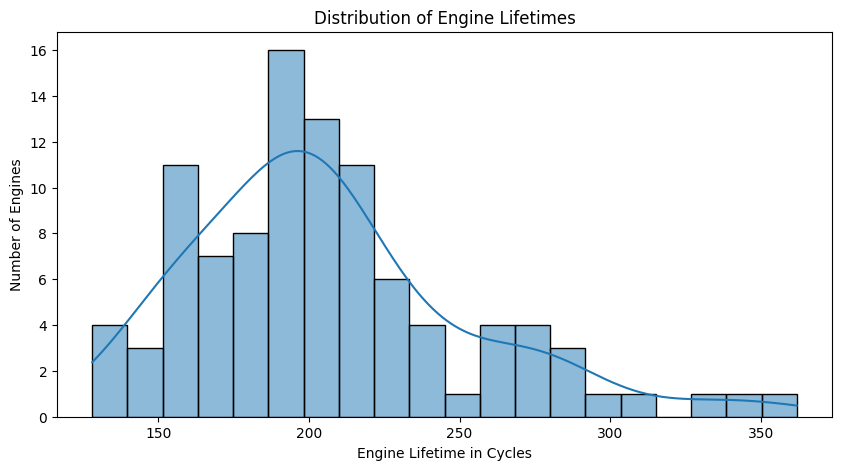

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(engine_life["engine_lifetime_cycles"], bins=20, kde=True)
plt.title("Distribution of Engine Lifetimes")
plt.xlabel("Engine Lifetime in Cycles")
plt.ylabel("Number of Engines")
plt.show()

In [6]:
risk_counts = train_df["risk_label"].value_counts()

display(risk_counts)

risk_label
Low Risk       13031
Medium Risk     4500
High Risk       3100
Name: count, dtype: int64

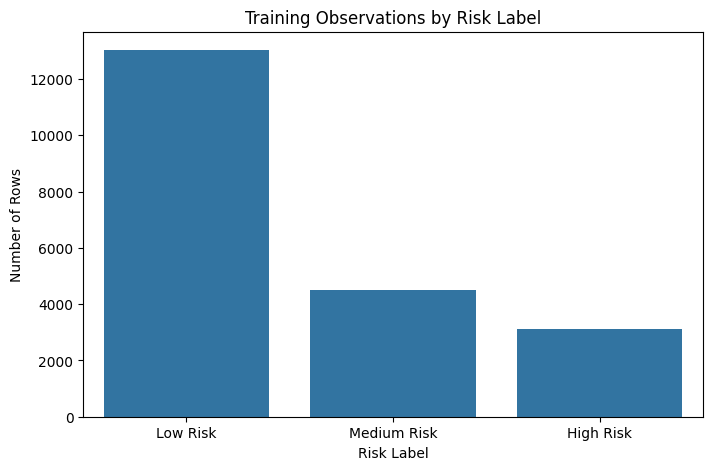

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x="risk_label", order=["Low Risk", "Medium Risk", "High Risk"])
plt.title("Training Observations by Risk Label")
plt.xlabel("Risk Label")
plt.ylabel("Number of Rows")
plt.show()

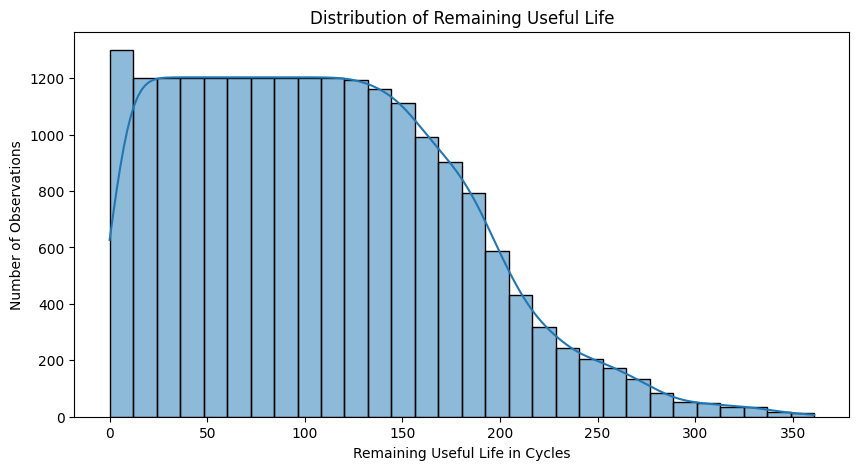

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(train_df["RUL"], bins=30, kde=True)
plt.title("Distribution of Remaining Useful Life")
plt.xlabel("Remaining Useful Life in Cycles")
plt.ylabel("Number of Observations")
plt.show()

In [9]:
rul_by_risk = (
    train_df
    .groupby("risk_label")["RUL"]
    .agg(["count", "mean", "min", "max"])
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
)

display(rul_by_risk)

,count,mean,min,max
risk_label,,,,
Low Risk,13031,148.813138,76,361
Medium Risk,4500,53.000000,31,75
High Risk,3100,15.000000,0,30


In [10]:
sensor_columns = [f"sensor_{i}" for i in range(1, 22)]

sensor_columns

['sensor_1',
 'sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_5',
 'sensor_6',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_10',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_16',
 'sensor_17',
 'sensor_18',
 'sensor_19',
 'sensor_20',
 'sensor_21']

In [11]:
sensor_by_risk = (
    train_df
    .groupby("risk_label")[sensor_columns]
    .mean()
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
)

display(sensor_by_risk)

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
risk_label,,,,,,,,,,,,,,,,,,,,,
Low Risk,518.67,642.457230,1587.871857,1404.469447,14.62,21.609700,553.794162,2388.067758,9058.613871,1.3,...,521.777248,2388.066922,8139.175767,8.424365,0.03,392.517382,2388.0,100.0,38.899714,23.339907
Medium Risk,518.67,642.852456,1592.556987,1412.301013,14.62,21.609967,553.039873,2388.117187,9069.262142,1.3,...,521.133536,2388.117187,8146.348293,8.455618,0.03,393.738889,2388.0,100.0,38.752269,23.251882
High Risk,518.67,643.372297,1598.715435,1422.811913,14.62,21.610000,552.050997,2388.188297,9087.274232,1.3,...,520.290668,2388.188490,8159.224410,8.497328,0.03,395.358065,2388.0,100.0,38.558419,23.133585


In [12]:
sensor_change = pd.DataFrame({
    "low_risk_avg": sensor_by_risk.loc["Low Risk"],
    "high_risk_avg": sensor_by_risk.loc["High Risk"]
})

sensor_change["absolute_change"] = (
    sensor_change["high_risk_avg"] - sensor_change["low_risk_avg"]
).abs()

sensor_change = sensor_change.sort_values("absolute_change", ascending=False)

display(sensor_change.head(10))

,low_risk_avg,high_risk_avg,absolute_change
sensor_9,9058.613871,9087.274232,28.660361
sensor_14,8139.175767,8159.224410,20.048643
sensor_4,1404.469447,1422.811913,18.342466
sensor_3,1587.871857,1598.715435,10.843578
sensor_17,392.517382,395.358065,2.840683
sensor_7,553.794162,552.050997,1.743166
sensor_12,521.777248,520.290668,1.486580
sensor_2,642.457230,643.372297,0.915066
sensor_11,47.405223,47.963948,0.558725
sensor_20,38.899714,38.558419,0.341294


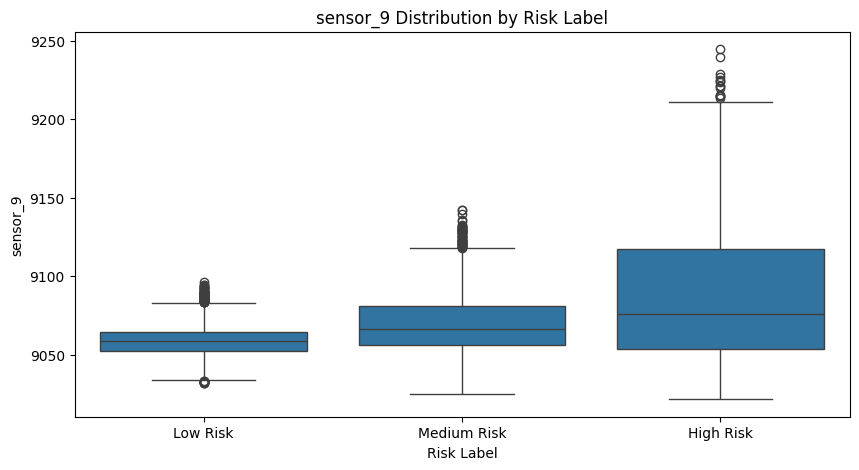

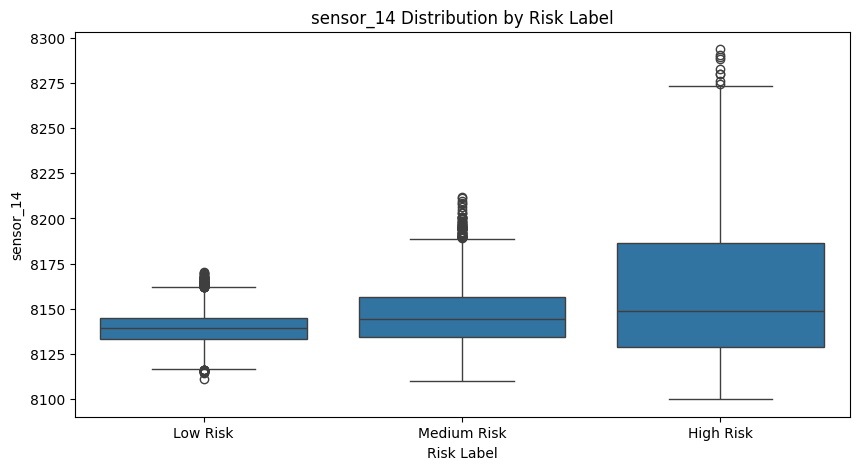

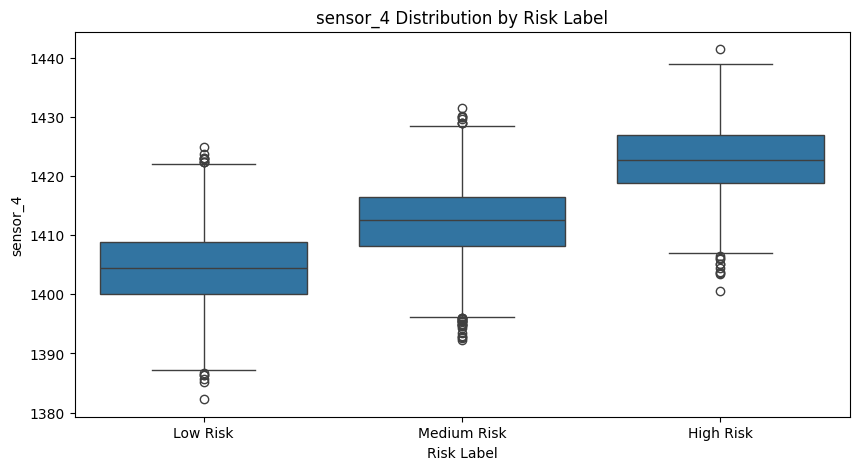

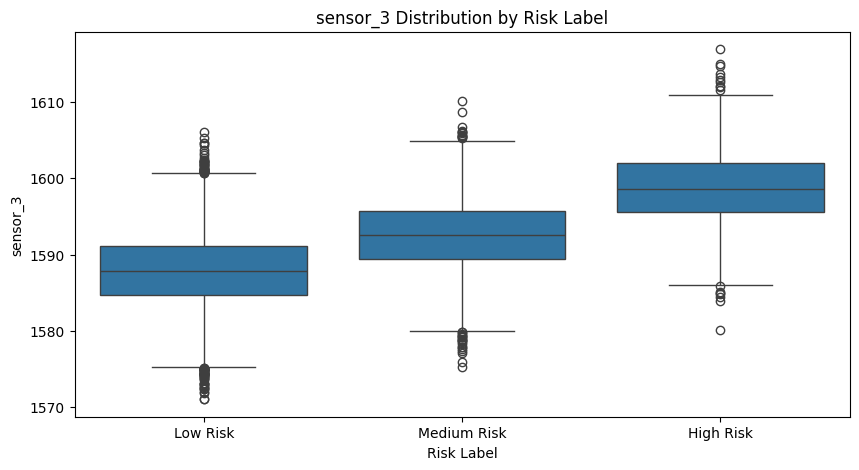

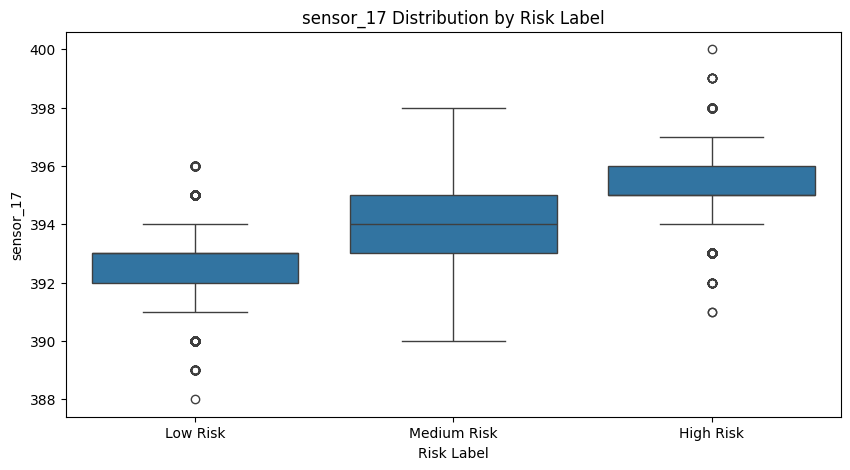

In [13]:
top_sensors = sensor_change.head(5).index.tolist()

for sensor in top_sensors:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=train_df, x="risk_label", y=sensor, order=["Low Risk", "Medium Risk", "High Risk"])
    plt.title(f"{sensor} Distribution by Risk Label")
    plt.xlabel("Risk Label")
    plt.ylabel(sensor)
    plt.show()

In [14]:
train_df["life_percent"] = train_df["time_in_cycles"] / train_df["max_cycle"]

display(train_df[["unit_number", "time_in_cycles", "max_cycle", "life_percent", "RUL"]].head())

,unit_number,time_in_cycles,max_cycle,life_percent,RUL
0,1,1,192,0.005208,191
1,1,2,192,0.010417,190
2,1,3,192,0.015625,189
3,1,4,192,0.020833,188
4,1,5,192,0.026042,187


In [15]:
train_df["life_stage"] = pd.cut(
    train_df["life_percent"],
    bins=[0, 0.25, 0.50, 0.75, 1.00],
    labels=["Early Life", "Mid Life", "Late Life", "End of Life"],
    include_lowest=True
)

display(train_df[["unit_number", "time_in_cycles", "life_percent", "life_stage", "RUL"]].head())

,unit_number,time_in_cycles,life_percent,life_stage,RUL
0,1,1,0.005208,Early Life,191
1,1,2,0.010417,Early Life,190
2,1,3,0.015625,Early Life,189
3,1,4,0.020833,Early Life,188
4,1,5,0.026042,Early Life,187


In [16]:
sensor_by_life_stage = (
    train_df
    .groupby("life_stage", observed=True)[sensor_columns]
    .mean()
)

display(sensor_by_life_stage)

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
life_stage,,,,,,,,,,,,,,,,,,,,,
Early Life,518.67,642.380471,1586.910787,1402.775563,14.62,21.609566,553.946116,2388.058040,9056.356973,1.3,...,521.909060,2388.056753,8137.605811,8.418241,0.03,392.271981,2388.0,100.0,38.933066,23.358816
Mid Life,518.67,642.464406,1587.940344,1404.598426,14.62,21.609745,553.785298,2388.068656,9058.182862,1.3,...,521.768277,2388.068010,8138.892367,8.424682,0.03,392.515468,2388.0,100.0,38.896031,23.338931
Late Life,518.67,642.663034,1590.305223,1408.663083,14.62,21.609903,553.392062,2388.094882,9063.913759,1.3,...,521.433810,2388.094358,8142.581304,8.440875,0.03,393.170457,2388.0,100.0,38.820608,23.292179
End of Life,518.67,643.210137,1596.867825,1419.582929,14.62,21.609996,552.358220,2388.164301,9082.339120,1.3,...,520.552011,2388.164750,8155.805185,8.484333,0.03,394.867013,2388.0,100.0,38.617542,23.170185


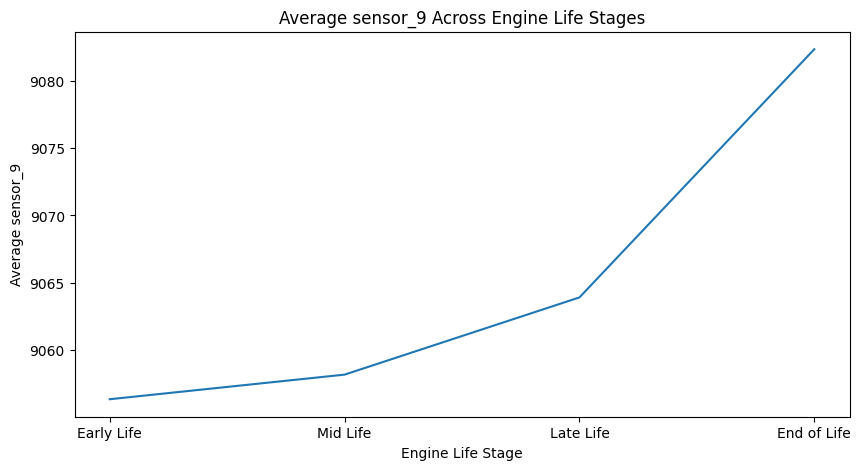

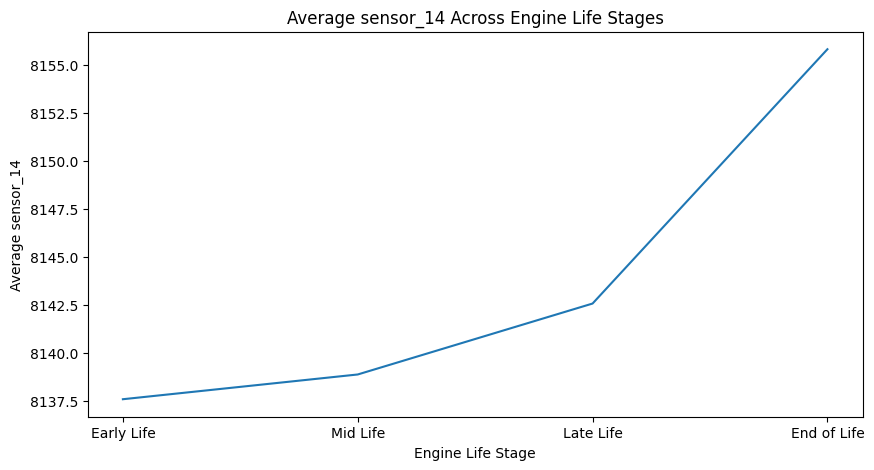

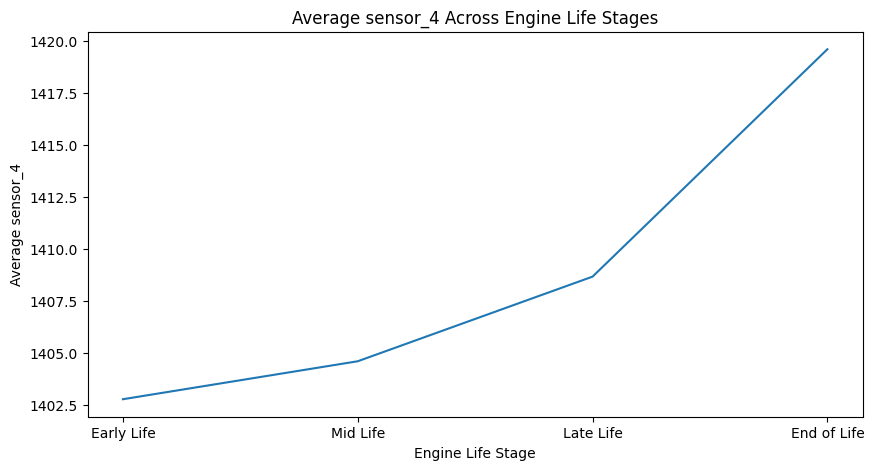

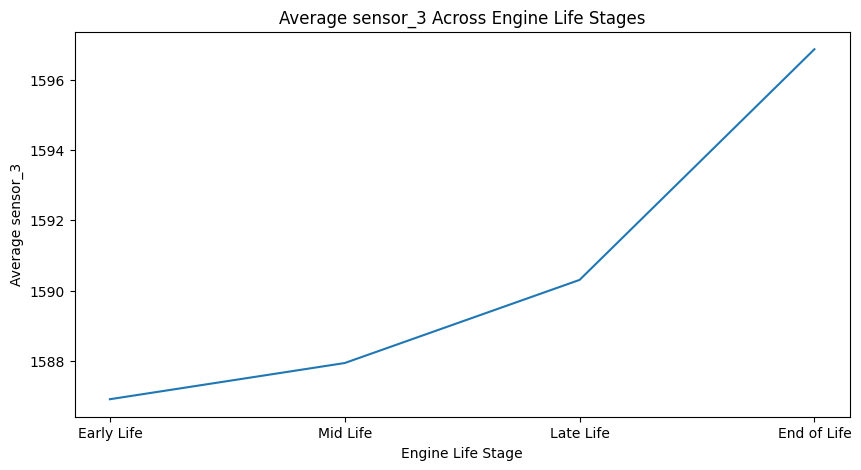

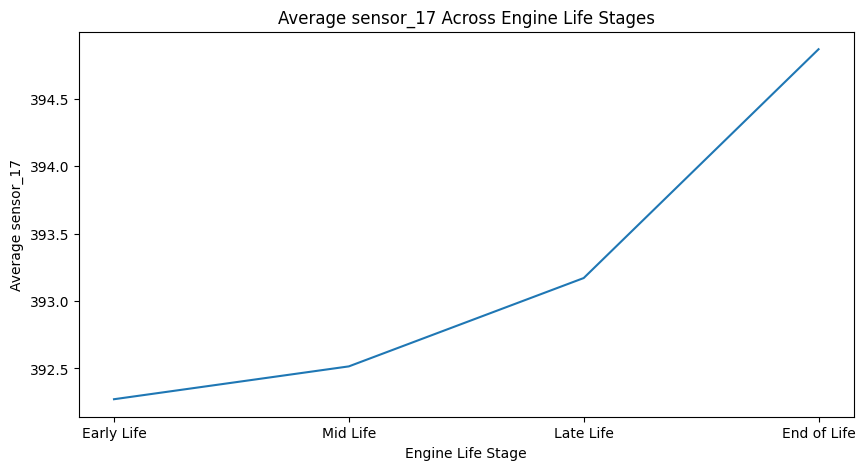

In [17]:
for sensor in top_sensors:
    plt.figure(figsize=(10, 5))
    sns.lineplot(
        data=train_df,
        x="life_stage",
        y=sensor,
        estimator="mean",
        errorbar=None
    )
    plt.title(f"Average {sensor} Across Engine Life Stages")
    plt.xlabel("Engine Life Stage")
    plt.ylabel(f"Average {sensor}")
    plt.show()

In [18]:
risk_counts.to_csv("../data/outputs/risk_label_counts.csv")
rul_by_risk.to_csv("../data/outputs/rul_summary_by_risk.csv")
sensor_change.to_csv("../data/outputs/sensor_change_low_vs_high_risk.csv")
sensor_by_life_stage.to_csv("../data/outputs/sensor_summary_by_life_stage.csv")

print("EDA summary files saved to data/outputs/")

EDA summary files saved to data/outputs/
